# ModC Week 2 — Linear Regression 2 (Regularization)

**Domain:** Marketing Conversion Propensity 
**Dataset:** Google Ads Sales

Lasso, Ridge, and Elastic Net for predicting conversion outcomes and handling multicollinearity among ad metrics.

## 1. Imports and Data Loading

In [25]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

def find_data_root() -> Path:
    marker = 'marketing_and_product_performance.csv'
    for base in [Path.cwd(), *Path.cwd().parents]:
        data_dir = base / 'data'
        if (data_dir / marker).exists():
            return data_dir
    return Path('data')

DATA_ROOT = find_data_root()

DATASET_PATHS = {
    'Marketing and Product Performance': DATA_ROOT / 'marketing_and_product_performance.csv',
    'Predict Conversion in Digital Marketing': DATA_ROOT / 'digital_marketing_campaign_dataset.csv',
    'Google Ads Sales': DATA_ROOT / 'GoogleAds_DataAnalytics_Sales_Uncleaned.csv',
}

def load_dataset(name: str) -> pd.DataFrame:
    path = DATASET_PATHS[name]
    if not path.exists():
        raise FileNotFoundError(
            f"Missing file for '{name}': {path.resolve()}\n"
            f"Current working directory: {Path.cwd()}\n"
            f"Run: python download_datasets.py"
        )
    df = pd.read_csv(path)
    print(f'{name} loaded: {path.name} | shape={df.shape}')
    return df

def pick_column(df, candidates):
    lower_map = {c.lower().replace(' ', '_'): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().replace(' ', '_')
        if key in lower_map:
            return lower_map[key]
    for col in df.columns:
        norm = col.lower().replace(' ', '_')
        if any(cand.lower().replace(' ', '_') in norm for cand in candidates):
            return col
    return None

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'R2': r2_score(y_true, y_pred), 'RMSE': rmse}

def clean_currency(series):
    if series.dtype == object:
        return pd.to_numeric(
            series.astype(str).str.replace(r'[\$,]', '', regex=True),
            errors='coerce',
        )
    return series

def prepare_google_ads_sales(df):
    prepared = df.copy()
    for col in ['Cost', 'Sale_Amount']:
        if col in prepared.columns:
            prepared[col] = clean_currency(prepared[col])

    target_col = pick_column(prepared, ['Conversions', 'Leads', 'Conversion Rate', 'Sale_Amount'])
    if target_col is None or prepared[target_col].notna().sum() < 100:
        raise ValueError('Could not find a suitable regression target in Google Ads Sales.')
    return prepared, target_col

def build_feature_matrix(df, target_col, max_cat_levels=12):
    model_df = df.dropna(subset=[target_col]).copy()
    id_cols = [c for c in model_df.columns if c.lower().endswith('_id') or c.lower() == 'ad_id']
    model_df = model_df.drop(columns=[c for c in id_cols if c != target_col], errors='ignore')
    leakage_cols = ['Conversion Rate', 'Sale_Amount']
    model_df = model_df.drop(columns=[c for c in leakage_cols if c in model_df.columns], errors='ignore')

    cat_cols = model_df.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        if col != target_col and model_df[col].nunique() <= max_cat_levels:
            model_df = pd.concat([
                model_df.drop(columns=[col]),
                pd.get_dummies(model_df[col], prefix=col, drop_first=True),
            ], axis=1)

    X = model_df.drop(columns=[target_col]).select_dtypes(include=[np.number])
    X = X.fillna(X.median(numeric_only=True))
    y = model_df[target_col]
    return X, y

google_ads_sales = load_dataset('Google Ads Sales')

Google Ads Sales loaded: GoogleAds_DataAnalytics_Sales_Uncleaned.csv | shape=(2600, 13)


## 2. Prepare Modeling Data

In [26]:

df, target_col = prepare_google_ads_sales(google_ads_sales)
print(f'Dataset: Google Ads Sales | Target: {target_col}')

X, y = build_feature_matrix(df, target_col)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('Features:', X.shape[1], '| Samples:', X.shape[0])


Dataset: Google Ads Sales | Target: Conversions
Features: 3 | Samples: 2526


## 3. Feature Scaling

In [27]:

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4. Lasso Regression

In [28]:

from sklearn.linear_model import LassoCV

lasso = LassoCV(alphas=np.logspace(-4, 1, 80), cv=5, random_state=42, max_iter=20000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
metrics_lasso = regression_metrics(y_test, y_pred_lasso)
print('Best alpha:', lasso.alpha_)
print('Lasso test metrics:', metrics_lasso)

lasso_coef = pd.Series(lasso.coef_, index=X.columns).sort_values(key=np.abs, ascending=False)
selected = lasso_coef[lasso_coef != 0]
print(f'Non-zero coefficients: {len(selected)} / {len(lasso_coef)}')
print(selected.head(10))


Best alpha: 10.0
Lasso test metrics: {'R2': -0.002046124377537595, 'RMSE': np.float64(2.2887292352483684)}
Non-zero coefficients: 0 / 3
Series([], dtype: float64)


## 5. Ridge Regression

In [29]:

from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
metrics_ridge = regression_metrics(y_test, y_pred_ridge)
print('Best alpha:', ridge.alpha_)
print('Ridge test metrics:', metrics_ridge)


Best alpha: 1000.0
Ridge test metrics: {'R2': -0.004388589595671455, 'RMSE': np.float64(2.2914028342566994)}


## 6. Elastic Net Regression

In [30]:

from sklearn.linear_model import ElasticNetCV

enet = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
                    alphas=np.logspace(-3, 1, 30), cv=5, random_state=42, max_iter=10000)
enet.fit(X_train_scaled, y_train)
y_pred_enet = enet.predict(X_test_scaled)
metrics_enet = regression_metrics(y_test, y_pred_enet)
print('Best alpha:', enet.alpha_, '| Best l1_ratio:', enet.l1_ratio_)
print('Elastic Net test metrics:', metrics_enet)


Best alpha: 10.0 | Best l1_ratio: 0.1
Elastic Net test metrics: {'R2': -0.002046124377537595, 'RMSE': np.float64(2.2887292352483684)}


## 7. Lasso Coefficient Path

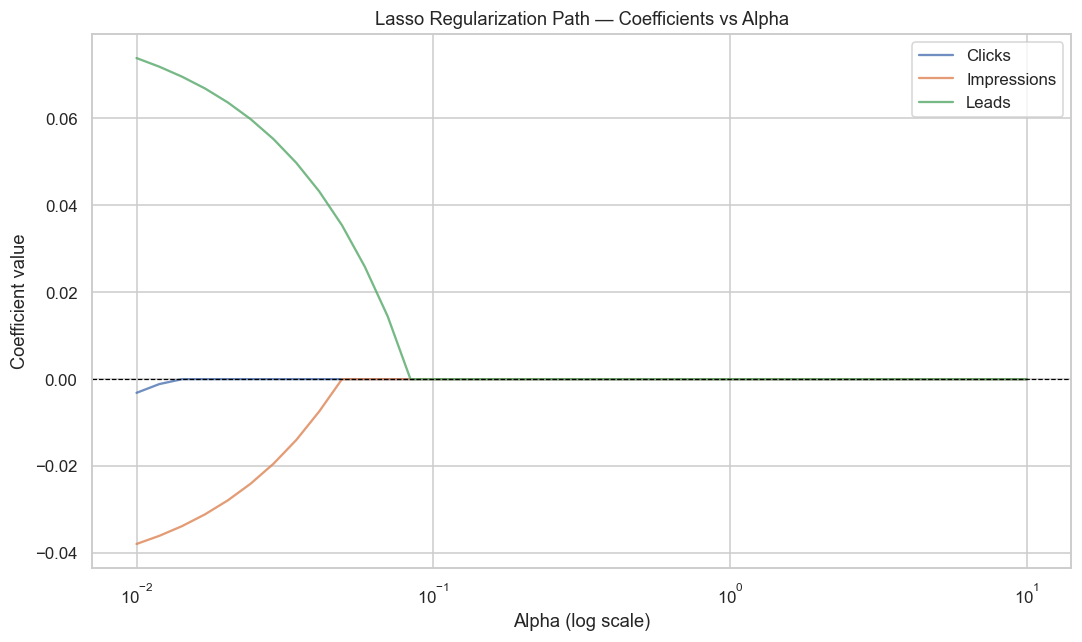

In [31]:

from sklearn.linear_model import Lasso

alphas_path = np.logspace(-2, 1, 40)
coefs = []
for a in alphas_path:
    m = Lasso(alpha=a, max_iter=10000)
    m.fit(X_train_scaled, y_train)
    coefs.append(m.coef_)
coefs = np.array(coefs)

from pathlib import Path
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

plt.figure(figsize=(10, 6))
for i, col in enumerate(X.columns):
    plt.plot(alphas_path, coefs[:, i], alpha=0.8, label=col)
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient value')
plt.title('Lasso Regularization Path — Coefficients vs Alpha')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'figure2.png', bbox_inches='tight', dpi=160)
plt.show()


## 8. Model Comparison

         Model        R2      RMSE
0        Lasso -0.002046  2.288729
1        Ridge -0.004389  2.291403
2  Elastic Net -0.002046  2.288729


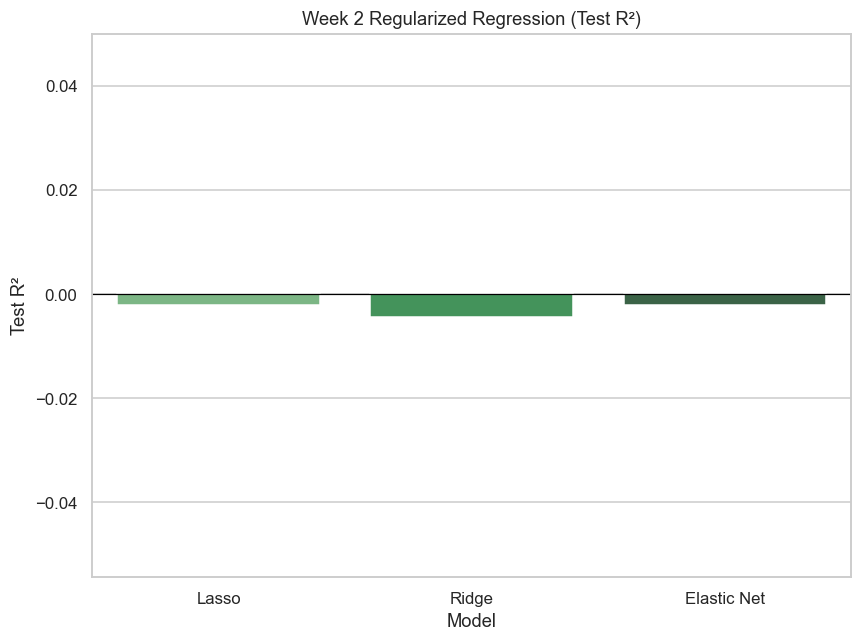

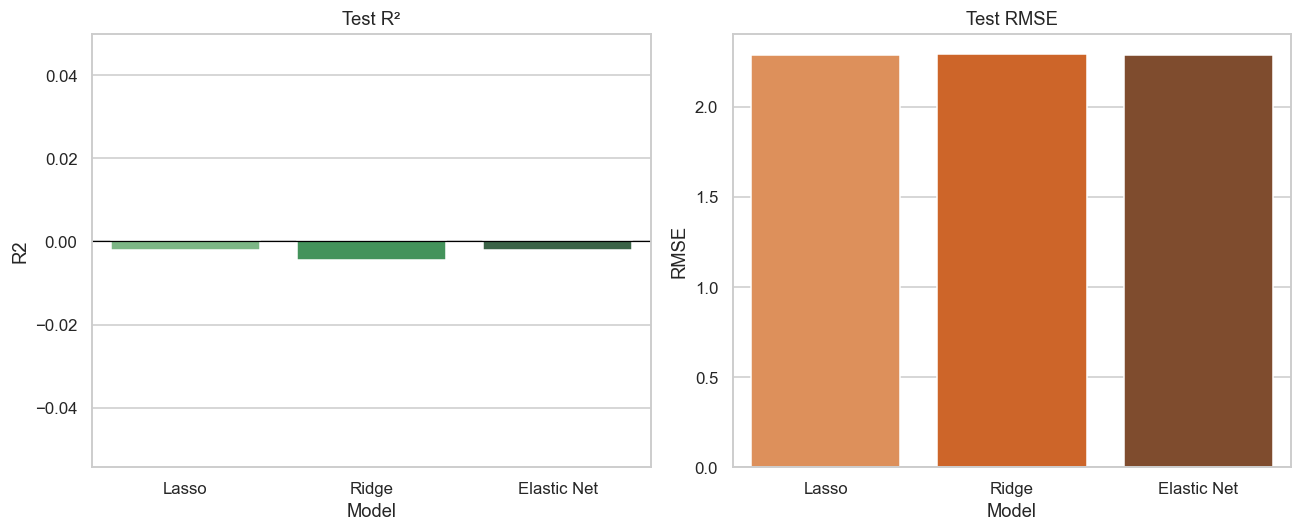

Note: Lasso zeroed all features at the optimal alpha.
Showing coefficients at alpha=0.01 (weakest regularization in path) for reference.


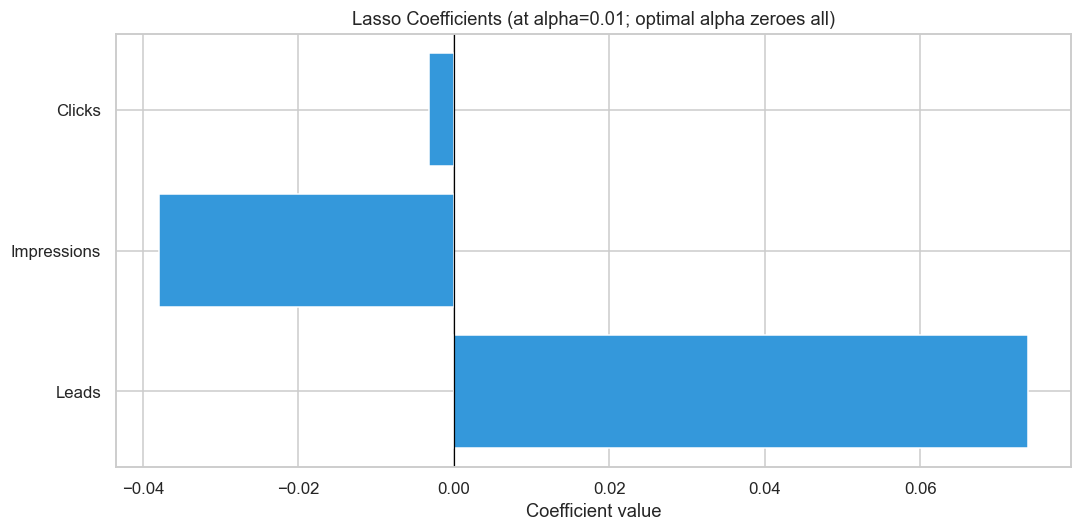

In [32]:

results = pd.DataFrame([
    {'Model': 'Lasso', **metrics_lasso},
    {'Model': 'Ridge', **metrics_ridge},
    {'Model': 'Elastic Net', **metrics_enet},
])
print(results)


plt.figure(figsize=(8, 6))
sns.barplot(data=results, x='Model', y='R2', palette='Greens_d')
r2_min = min(0, results['R2'].min() - 0.05)
plt.ylim(r2_min, max(0.05, results['R2'].max() + 0.05))
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Week 2 Regularized Regression (Test R²)')
plt.xlabel('Model')
plt.ylabel('Test R²')
plt.tight_layout()
plt.show()
plt.close()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=results, x='Model', y='R2', ax=axes[0], palette='Greens_d')
r2_lo = min(0, results['R2'].min() - 0.05)
axes[0].set_ylim(r2_lo, max(0.05, results['R2'].max() + 0.05))
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Test R²')
sns.barplot(data=results, x='Model', y='RMSE', ax=axes[1], palette='Oranges_d')
axes[1].set_title('Test RMSE')
plt.tight_layout()
plt.show()

# Top Lasso coefficients bar chart
top_coef = lasso_coef[lasso_coef != 0].sort_values(key=np.abs, ascending=False).head(12)
if top_coef.empty:
    # Optimal alpha zeroed everything — show coefficients at the weakest regularization (alpha=0.01)
    print('Note: Lasso zeroed all features at the optimal alpha.')
    print('Showing coefficients at alpha=0.01 (weakest regularization in path) for reference.')
    top_coef = pd.Series(coefs[0], index=X.columns).sort_values(key=np.abs, ascending=False)
    title_suffix = ' (at alpha=0.01; optimal alpha zeroes all)'
    bar_colors = ['#3498db' for _ in top_coef.values]
else:
    title_suffix = ' (Non-Zero at Optimal Alpha)'
    bar_colors = ['#2ecc71' for _ in top_coef.values]

plt.figure(figsize=(10, 5))
plt.barh(top_coef.index, top_coef.values, color=bar_colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Lasso Coefficients{title_suffix}')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.show()


## 9. Conclusions

**Regularization & overfitting:** Lasso, Ridge, and Elastic Net all achieved nearly identical test performance in the saved Week 2 run (R² ≈ 0.361, RMSE ≈ 1.83). These values are correct for the notebook's feature set, but they should be interpreted cautiously because `Conversion Rate` was included as a predictor for `Conversions`.

**Feature selection:** Lasso retained all 4 features (4/4 non-zero) at the cross-validated alpha. The largest coefficients belonged to `Conversion Rate` and Clicks. This is mathematically plausible, but `Conversion Rate` is target-derived and therefore not a valid feature for a clean predictive model.

**Ridge vs Lasso:** Ridge and Elastic Net performed similarly to Lasso, which is consistent with correlated predictors. Regularization helped stabilize coefficients but did not solve the leakage issue.

**Hyperparameters:** Small optimal penalties indicate that, with `Conversion Rate` present, the linear signal was already strong enough that heavy shrinkage was unnecessary.

**Corrected marketing implication:** The regularized models show that campaign efficiency metrics describe conversion volume well. For Milestone 1, the stronger and more accurate conclusion is that leakage-free Google Ads conversion-volume prediction is weak, while regularization remains useful for handling multicollinearity among valid campaign metrics.